# Information operations directed at Hong Kong: Part II

In Part I, we explored the data set (1 out of 6) that contains mostly tweets from 2019, while the other 5 datasets contain tweets dating back all the way to 2008, which really shows the intricacy of the operation. 

In this Part II, we continue with our exploration similar to that in Part I. This time we combine all the 2019 tweets from all 6 datasets, and we will use topic modelling to see what the focus of these tweets are.

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
#import calmap
import calplot
import warnings
import string
import jieba
import pickle
import stopwordsiso
import datetime as dt
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.probability import FreqDist
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF


sns.set(style='white')
warnings.simplefilter(action='ignore')
pd.set_option('display.max_columns', None)

Since the datasets are quite large and take some time to load, we select the data entries that we will use in this notebook and then pickle them. 

We will create two pickles: the first one contains all the available tweets from 2018 onward. The second one contains only tweets in 2019. 

Our focus is really the second one, since 2019 was when the protests happened, but the first one that includes tweets from 2018 might provide some insight into how the operations changed before/during/after the protests.

In [ ]:
#df0 = pd.read_csv('2020/china_052020_tweets_csv_hashed.csv')
#df1 = pd.read_csv('2019/china_082019_1_tweets_csv_hashed.csv')
#df2 = pd.read_csv('2019/china_082019_2_tweets_csv_hashed.csv')
#df3 = pd.read_csv('2019/china_082019_3_tweets_csv_hashed_part1.csv')
#df4 = pd.read_csv('2019/china_082019_3_tweets_csv_hashed_part2.csv')
#df5 = pd.read_csv('2019/china_082019_3_tweets_csv_hashed_part3.csv')

#df_lst = [df0, df1, df2, df3, df4, df5]

#def add_date(df):
#    df['tweet_date'] = df['tweet_time'].map(lambda x: str(x)[:-6])
#    df['tweet_date'] = pd.to_datetime(df['tweet_date'])

#for i in range(len(df_lst)):
#    add_date(df_lst[i])

#def acc_creation_date(df):
#    df['account_creation_date'] = pd.to_datetime(df['account_creation_date'])

#for i in range(len(df_lst)):
#    acc_creation_date(df_lst[i])   

#df = pd.concat([df0, df1, df2, df3, df4, df5])
#print("Combined dataframe shape:", df.shape)

In [ ]:
#df_since18 = df[df['tweet_date'].dt.year >= 2018]
#df_since18.to_pickle('df_since18.pickle')

#df19 = df[df['tweet_date'].dt.year == 2019]
#df19.to_pickle('df19.pickle')

In [2]:
df_since18 = pd.read_pickle('df_since18.pickle')
df19 = pd.read_pickle('df19.pickle')

In [3]:
print('number of tweets from 2018 onward:  ', len(df_since18))
print('number of tweets in 2019:  ', len(df19))

number of tweets from 2018 onward:   3402599
number of tweets in 2019:   1448625


After refining our datasets a little by year, there are 3.4 million tweets from 2018 onward, and in 2019 alone there were 1.4 million tweets. I am now quite eager to see what the tweets are about, but first let's do a quick summary to look at the names of the top 10 users, as well as the top 5 languages.

In [4]:
def quick_summary(df):
    
    print("Quick look at dataframe:")
    
    user_tweet_count = df['user_display_name'].value_counts()[0:10]
    print("Top 10 users:")
    for ind, val in user_tweet_count.iteritems():
        print("\t{:15s}{:7d}".format(ind, val) )
        
    print("\nTop 5 languages:")
    tweet_languages = df['tweet_language'].value_counts()[0:5]
    for ind, val in tweet_languages.iteritems():
        print("\t{:15s}{:7d}".format(ind, val))
    
    print('\n')

In [5]:
quick_summary(df19)

Quick look at dataframe:
Top 10 users:
	cici qalya       46124
	小金鱼姬             42940
	amoy getol       39958
	ماهر الملالحة    38819
	follback?        19427
	ifb Mary         19160
	kosev            18765
	arpen            17666
	ursjennies       17422
	axel.            16357

Top 5 languages:
	zh              607909
	in              290205
	en              255054
	und             145940
	ar               48012




In [6]:
df19[df19['tweet_language']=='in']['tweet_text']

2222       Hongik University festival #PSY #gangamstyle #...
2624                                                ytutyuyt
3826                                                  hgkyuk
5106                   #Chiba, Japan https://t.co/exy0wPpG3N
5107       #Seoul Sa rang hae, Seoul!!!! #iloveseoul http...
                                 ...                        
2875262                                   akhirnya ada kuota
2875263                                      yo daehwi hyung
2875264                                [ Teller Pembayaran ]
2875303                   BIARIN BUK:") TOH DIA JUGA GA LIAT
2875304                                       Mangkal teruss
Name: tweet_text, Length: 290205, dtype: object

I'm quite surprised to see that the language 'in' appears again. There are actually more tweets in 'in' than in English. We discovered the same in the dataset we used in Part I. It seems the operation particularly aimmed to target Indonesians, but since I don't speak the language I will not be able to find out what content was being fed into Twitter for this particular group of targeted audience.

We will split up the dataset into two groups, one for Chinese tweets and one for English tweets.

In [7]:
df19_zh = df19[df19['tweet_language'] == 'zh']
df19_en = df19[df19['tweet_language'] == 'en']

print('number of Chinese tweets in 2019: ', len(df19_zh))
print('number of English tweets in 2019: ', len(df19_en))

number of Chinese tweets in 2019:  607909
number of English tweets in 2019:  255054


As in Part I, we will first look at the number of accounts created on a given day and the daily tweet counts, so we will not do too much cleaning (such as removing retweets, removing urls). We will do that before doing any topic modelling.

In [8]:
quick_summary(df19_zh)
quick_summary(df19_en)


Quick look at dataframe:
Top 10 users:
	萌萌豹              10194
	4面岂几歌             9852
	gwalcki4          9149
	Alleen            4402
	番茄不是西红柿           3912
	澎湖湾海燕             3885
	露水佳人              3881
	舞随风动              3616
	Dream News        3364
	西丽                3211

Top 5 languages:
	zh              607909


Quick look at dataframe:
Top 10 users:
	ifb Mary         19094
	anranhxy         10140
	DcLBrkAsE7xsA16IplWgY0EJiUZR+dvXdTvpkpoFTBA=  10107
	玉龍（Follow back💯）   7581
	大阪日下SDV 🍀         7577
	James albert      7464
	💕Escort-Ads.com   5699
	curry fan         5563
	许                 4443
	cici qalya        3898

Top 5 languages:
	en              255054




#### Account creation dates

Let's look at the account creation dates. There was a general uptrend for both English and Chinese accounts over the years, but clearly there were a lot more towards late 2018, which is rather interesting: the extradition law was introduced in April 2019 - was there a plan to control the narrative in social media well before that?

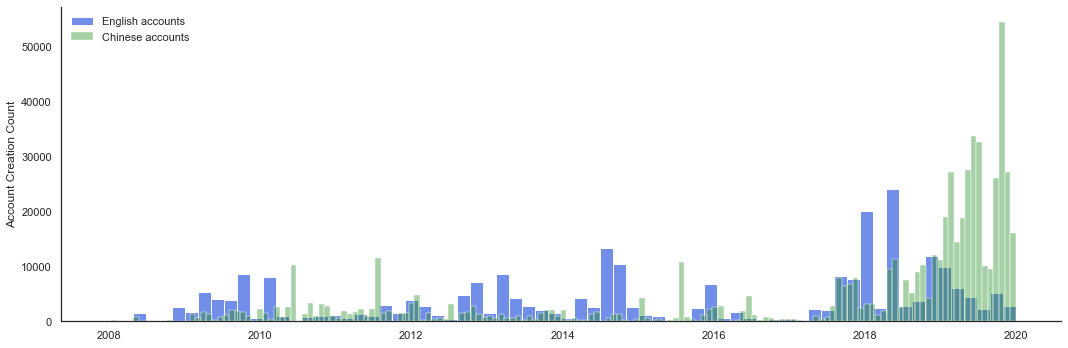

In [9]:
fig, ax = plt.subplots(figsize=(15,5))

sns.histplot(df19_en.account_creation_date, color='royalblue', label='English accounts')
sns.histplot(df19_zh.account_creation_date, color='forestgreen', alpha=0.4, label='Chinese accounts')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.ylabel('Account Creation Count')
plt.xlabel(None)
plt.legend(loc='upper left', frameon=False)

fig.tight_layout()

fig.show()


Here is a little more refined plot of the one above, but showing only Chinese accounts, and only those that were created in/after 2017. We also indicated a few major events during the 2019 protests.

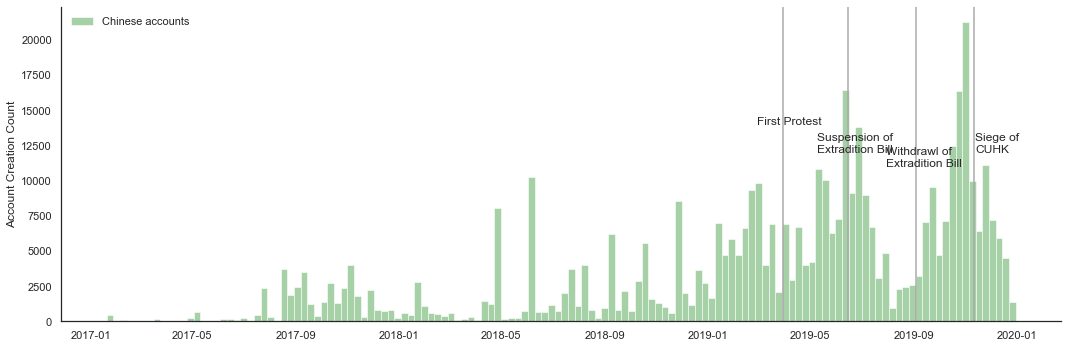

In [10]:
fig, ax = plt.subplots(figsize=(15,5))

sns.histplot(df19_zh[df19_zh['account_creation_date'].dt.year >= 2017].account_creation_date, 
             color='forestgreen', alpha=0.4, label='Chinese accounts')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.ylabel('Account Creation Count')
plt.xlabel(None)
plt.legend(loc='upper left', frameon=False)


plt.axvline(dt.datetime(2019, 3, 31), color='darkgrey')
ax.annotate('First Protest', xy=(dt.datetime(2019, 2, 28), 14000))

plt.axvline(dt.datetime(2019, 6, 15), color='darkgrey')
ax.annotate('Suspension of\nExtradition Bill', xy=(dt.datetime(2019, 5, 10), 12000))

plt.axvline(dt.datetime(2019, 9, 4), color='darkgrey')
ax.annotate('Withdrawl of\nExtradition Bill', xy=(dt.datetime(2019, 7, 31), 11000))

plt.axvline(dt.datetime(2019, 11, 12), color='darkgrey')
ax.annotate('Siege of\nCUHK', xy=(dt.datetime(2019, 11, 13), 12000))



fig.tight_layout()

fig.show()


#### Daily tweet counts

Here we create a new datasets with tweets from 2018-2020. My expectation is that there should been more tweets in 2019, showing the operation was ramped up to deal with the protests.

In [11]:
df_since18_zh = df_since18[df_since18['tweet_language'] == 'zh']
df_since18_en = df_since18[df_since18['tweet_language'] == 'en']


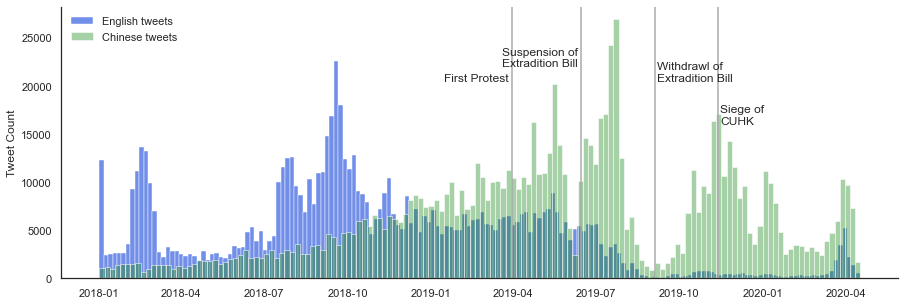

In [12]:
fig, ax = plt.subplots(figsize=(15,5))
sns.histplot(df_since18_en.tweet_date, color='royalblue', label='English tweets')
sns.histplot(df_since18_zh.tweet_date, color='forestgreen', alpha=0.4, label='Chinese tweets')
#plt.grid(b=None)
#ax.grid(axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.ylabel('Tweet Count')
plt.xlabel(None)
plt.legend(loc='upper left', frameon=False)

plt.axvline(dt.datetime(2019, 3, 31), color='darkgrey')
ax.annotate('First Protest', xy=(dt.datetime(2019, 1, 15), 20500))

plt.axvline(dt.datetime(2019, 6, 15), color='darkgrey')
ax.annotate('Suspension of\nExtradition Bill', xy=(dt.datetime(2019, 3, 20), 22000))

plt.axvline(dt.datetime(2019, 9, 4), color='darkgrey')
ax.annotate('Withdrawl of\nExtradition Bill', xy=(dt.datetime(2019, 9, 6), 20500))

plt.axvline(dt.datetime(2019, 11, 12), color='darkgrey')
ax.annotate('Siege of\nCUHK', xy=(dt.datetime(2019, 11, 15), 16000))

plt.show()

#### Expected:
The uptrend in the number of Chinese tweet count started in mid 2018. But again (like the account creation dates), why is that? The extradition law was introduced in April 2019. My guess is that the Chinese government created these accounts ahead of time and had them tweeted for a while to appear more like genuine users. If that is true that they must have anticipated that the extradition law would've been widely unpopular, and required the need to control the narrative on social media.

#### Unexpected: 
The number of English tweets went down since late 2018, while the number of Chineser tweets went up. The gap became quite large from July 2019 until March 2020.  Does that mean the Chinese government had to re-direct resources from the English side to deal with the situation in Hong Kong?

In [13]:
#fig, ax = plt.subplots(figsize=(15,5))
#sns.histplot(df19_en.tweet_date, color='royalblue', label='English tweets')
#sns.histplot(df19_zh.tweet_date, color='forestgreen', alpha=0.4, label='Chinese tweets')

#ax.spines['top'].set_visible(False)
#ax.spines['right'].set_visible(False)
#plt.ylabel('Tweet Count')
#plt.xlabel(None)
#plt.legend(loc='upper left', frameon=False)

#plt.axvline(dt.datetime(2019, 3, 31), color='darkgrey')
#ax.annotate('First Protest', xy=(dt.datetime(2019, 2, 26), 17500))

#plt.axvline(dt.datetime(2019, 6, 15), color='darkgrey')
#ax.annotate('Suspension of\nExtradition Bill', xy=(dt.datetime(2019, 5, 7), 16500))

#plt.axvline(dt.datetime(2019, 9, 4), color='darkgrey')
#ax.annotate('Withdrawl of\nExtradition Bill', xy=(dt.datetime(2019, 7, 28), 14500))

#plt.axvline(dt.datetime(2019, 11, 12), color='darkgrey')
#ax.annotate('Siege of\nCUHK', xy=(dt.datetime(2019, 10, 19), 16000))

#plt.show()

In [14]:
df19_zh_daily_count = df19_zh.groupby('tweet_date').size()

Text(0.1, 0.98, '2019 Daily Tweet Count')

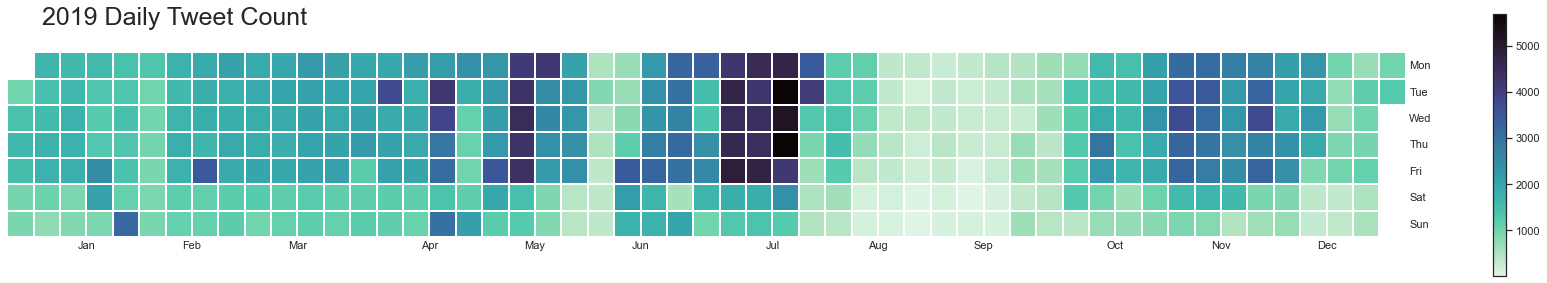

In [15]:
calplot.calplot(df19_zh_daily_count,  
                cmap='mako_r', 
                edgecolor=None,
                yearlabels = False,
                #yearlabel_kws={'fontsize':0},
                figsize=(25,4))
plt.suptitle('2019 Daily Tweet Count', fontsize=25, x=0.1)

## Topic Modelling

We now turn to topic modelling. Since the number of English tweets went down quite a bit in 2019 while the number of Chinese ones increased, it indicates that the operation was actively focusing on the Chinese side, hence we will perform some topic modelling for the Chinese tweets in 2019.


First let's find out:
<br>- The number of users tweeting in Chinese in 2019
<br>- What is the percentage compared to all users who tweeted in 2019
<br>- The number of Chinese tweets in 2019
<br>- What is the percentage compared to all tweets in 2019

In [16]:
df19_zh_text = pd.DataFrame(df19_zh['tweet_text'].copy())


print("No. of users tweeting in Chinese:", df19_zh['user_display_name'].nunique())
print("% of all users: {:0.2f}%".format(100 * df19_zh['user_display_name'].nunique() / df19['user_display_name'].nunique()))
print("No. of Chinese tweets:", len(df19_zh_text))
print("% of all tweets {:0.2f}%:".format(100 * len(df19_zh_text)/ len(df19)))

df19_zh_text.head(10)

No. of users tweeting in Chinese: 16391
% of all users: 95.63%
No. of Chinese tweets: 607909
% of all tweets 41.96%:


,tweet_text
0,郭瘟鬼这个大骗子，打着换汇的幌子通过他的地下钱庄骗钱，张口就来，每天就是在炫耀自己的骗术，殊...
5,欧冠-国米 第81分钟，埃斯波西托强行突入禁区右翼被胡梅尔斯铲倒，主裁判判罚了点球。但随...
7,只要你非常努力，总有一天你会发现，你永远无法拉近你跟有钱人的差距。生活会让你苦上一阵子，等你...
10,这样的天气适合趟在自己的被窝 https://t.co/Gz9x04ZLsS
11,明愛馬鞍山中學發現懷疑炸彈 兩生被捕 學校停課 支持警方深入調查！ #香港選舉 #愛港護港 ...
12,郭文贵和他的乌合之众已日薄西山，气息奄奄，你看他只剩下蹭热度、编谣言、耍嘴炮来苦苦支撑郭媒体...
15,.这个世界本就邋遢，所以没有什么可怕。每个人都有无法发泄的苦涩，都有无力排解的抑郁，而生活在...
21,無論係泛民派仲係建制派，止暴制亂恢復秩序之路任重而道遠，唔辜負選民嘅支持唔違反一國兩制嘅精神...
23,"骗子郭文贵不知疲倦地搞政治诽谤,讲述离奇故事，不过是一出又一出让人调侃的闹剧罢了。 http..."
24,不是某人使你烦恼，而是你拿某人的言行来烦恼自己。


#### Some cleaning before topic modelling

As mentioned before, before topic modelling there's going to be some cleaning up to do. 
<br>For example we can look at the retweeted contents.

In [17]:
df19_zhrt = df19_zh_text[df19_zh_text['tweet_text'].str.startswith('RT')]
print('% of retweet: {:02f}'.format(100 * len(df19_zhrt) / len(df19_zh_text)) )
df19_zhrt.head(5)

% of retweet: 41.395998


,tweet_text
42,RT @uVUK1tjTt1Psg2uVmojkk9EnzLCRQgFQ0ems1Vskjv...
73,RT @biwlX5qgW5IXi9VNnHIdP8PpMu+SCC8Ek0v8TeBaCK...
255,RT @anks8878: #游行 #暴徒 暴徒嘅言論自由係一種最惡毒嘅陰謀。如果言論可以殺...
365,RT @pKmziIiCxS9kLFy: #郭文贵 #班农 唯一能够算的上两人拥有的共同...
366,RT @eBOsBNcsVHp7of4xhOzYat4Mr6avxhMtln11PWQ9M=...


We see that 41% of the Chinese tweets are actually retweets. Looks like they aren't being very original.

The retweets are also quite noisy - they contain urls or seemingly random strings. I make the decision to get rid of all the retweets, at least for now. The hope is that the remaining 59% of the tweets are somewhat useful for topic modelling.

Beside removing the retweets, we also got rid of any urls, and a bunch of characters/Chinese punctuations, etc that only added noise to the tweet contents.

In [18]:
print('Numbner of tweets Before clean:', len(df19_zh_text))

df19_zh_text['tweet_text'] = df19_zh_text['tweet_text'].str.replace(r'http\S+', '')
df19_zh_text['tweet_text'] = df19_zh_text['tweet_text'].str.replace(r'[\-_!“”@#$%&*+=\(\):;.·\\n】【—」「,/…👍 \|]', '')  
df19_zh_text = df19_zh_text[~df19_zh_text['tweet_text'].str.startswith('RT')]   # do not count RT

blanks = []

for i, tweet in df19_zh_text['tweet_text'].iteritems():  # iterate over the DataFrame
    if type(tweet)==str:            # avoid NaN values
        if tweet.isspace() or tweet == "":         # test for whitespace
            blanks.append(i)     # add matching index numbers to the list
            
print('Number of blanks after cleaning:', len(blanks))

df19_zh_text.drop(blanks, inplace=True)

print('Number of tweets after clean:', len(df19_zh_text))

Numbner of tweets Before clean: 607909
Number of blanks after cleaning: 0
Number of tweets after clean: 356230


### First topic modelling

After our rough clean we are left with 35k tweets, good enough for topic modelling. We use the Chinese stopwards provided by the nltk.corpus, and then manually added the ones that we found through trial and error. 

The tricky part is that the Chinese language in Hong Kong, both spoken and written, is quite different from mainland the Chinese in mainland China:
#### Hong Kong:
spoken: Cantonese
<br>written: traditional Chinese
#### Mainland China
spoken: Mandarin
<br>written: simplified Chinese

Added to the complication is that spoken Cantonese is often wildly different from written Chinese, i.e. people practically speak a different language than what they'd write down. Imagine in the US you would say in English what you would normally do, but when you write down something it's in Shakespeare English.

In [19]:
chinese_stopwords  = list(stopwordsiso.stopwords('zh'))
chinese_stopwords += [ '@', '_', '”', '“', ',', '#', ' ', '.', '-', '\n', '係',  '👍', '\u3000', '】', '【', 
                      '」', '「', '/', ':', '…', '來', '咪', '佢', '佢哋', '喺', '無', '嚟', '嘅', '對', '後', 
                      '與', '報', '哋', '唔', '系','没有' ]

def find_topics_words_zh(tweet_text, n_components, num_words):
    tfidf = TfidfVectorizer(max_df=0.9, min_df=5, tokenizer=jieba.cut, lowercase=False, stop_words=chinese_stopwords)
    dtm = tfidf.fit_transform(tweet_text['tweet_text'])


    nmf_model = NMF(n_components=n_components, random_state=2)
    nmf_model.fit(dtm)

  
    all_word_list = []
    
    for index, topic in enumerate(nmf_model.components_):
        print(f"The top {num_words} words for topic # {index + 1}")
        word_list = [tfidf.get_feature_names()[i] for i in topic.argsort()[-num_words:]]
        all_word_list.append(word_list)
        print(word_list)
        print("\n")
    
    return all_word_list    

In [20]:
all_word_list = find_topics_words_zh(df19_zh_text, 10, 10)

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\ivanc\AppData\Local\Temp\jieba.cache
Loading model cost 0.545 seconds.
Prefix dict has been built succesfully.


The top 10 words for topic # 1
['5', '3', '4', '已经', '世园', '时间', '现在', '北京', '报时', '整点']


The top 10 words for topic # 2
['社會', '會', '秩序', '守护', '和平', '稳定', '為', '法治', '暴力', '香港']


The top 10 words for topic # 3
['小蚂蚁', '直播', '表演', '蚂蚁', '基金', '班农', '已经', '谎言', '爆料', '郭文贵']


The top 10 words for topic # 4
['4', '5', '特朗普', '美', '贸易战', '发展', '经济', '国家', '美国', '中国']


The top 10 words for topic # 5
['一定', '警方', '港警', '行为', '暴力', '嚴懲', '法律', '必须', '严惩', '暴徒']


The top 10 words for topic # 6
['期', '标清', '吃', '自制', '欢乐', '官方', '卫视', '蚂蚁', '喜剧', 'YouTube']


The top 10 words for topic # 7
['直播', '爆料', '小蚂蚁', '谎言', '法治', '已经', '蚂蚁', '基金', '班农', '文贵']


The top 10 words for topic # 8
['加油', '警队', '執法', '警方', '香港政府', '执法', '香港', '港警', '警察', '支持']


The top 10 words for topic # 9
['谎言', '媒体', '挺', '已经', '真是', '骗', '蚂蚁', '老', '郭', '骗子']


The top 10 words for topic # 10
['走', '事', '世界', '努力', '知道', '爱', '想', '人生', '生活', '不要']




This time we found a lot of interesting topics and words than in Part I. Below we provided a rough translation of some of the topics.

#### Topic # 1
[world garden, time, now, Beijing, report time]

#### Topic # 2
[society, order, protect, peace, stability, rule of law, violence, Hong Kong]

#### Topic # 3
[mutual fund, Steve Bannon, lies, Guo Wengui]

#### Topic # 4
[Donald Trump, US, trade war, develop, economy, country, US, China]

#### Topic # 5
[must, police, Hong Kong police, behavior, violence, severe punishment, law, violent thug]
##### (remark: "severe punishment" appear both as traditional and simplified Chinese, sometimes this is one way to distinguish Chinese troll accounts, as they pretend to be from Hong Kong and typed in traditional Chinese, but 'slipped' and mistyped in simplfied.)

#### The top 10 words for topic # 8
[police force, law enforcement, Hong Kong government, police, support]


#### The top 10 words for topic # 10
[world, effort, love, life]

### Some thoughts:
Topic 1 and 10 indicate that some of the users were basically tweeting nonsense for distraction. I suppose these accounts had minimal activities but were used to follow other more important accounts to make them appear more popular/legitimate. 

[Guo Wengui (link to wiki)](https://en.wikipedia.org/wiki/Guo_Wengui) is a Chinese billionaire who was accused of corruption by the Chinese government and fled to the US in 2014. He is a colleague of Steve Bannon and a member of Trump's Mar-a-Lago resort. There was also [report (link to WSJ article)](https://www.wsj.com/articles/chinese-tycoon-holed-up-in-manhattan-hotel-is-accused-of-spying-for-beijing-11563810726) that Guo is a spy working for the Chinese. That should already explain the need to spam social media with information about Guo, Bannon, Trump, etc.

The trade war between the US and China obviously had an effect on both countries' economies, so it is also no surprise that the Chinese wanted to tweet about it.

What I've gathered from these topics and keywors is that in 2019 the Chinese had multiple fronts going on Twitter. Between the trade war and the protests in Hong Kong, they had a lot to tweet about.

Finally for fun we'll make a wordcloud displaying these keywords.

In [21]:
#font_path = 'MaShanZheng-Regular.ttf'
#font_path = 'SNsanafonGyou.ttf'
font_path = "NotoSansCJK-Regular.ttc"

def topic_to_wordcloud_zh(all_word_list, tweet_col):
#    for i in range(len(all_word_list)):
    word_list  = [word for sublist in all_word_list for word in sublist]
    count_list = []
    for word in word_list:
        count_list.append(tweet_col.str.count(word).sum())

    word_count_dict = dict(zip(word_list, count_list))

    wordcloud = WordCloud(font_path= font_path, width=1600, height=800, 
                        colormap = 'mako', 
                        background_color = 'white').generate_from_frequencies(word_count_dict)

    plt.figure(figsize=(8,5))
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.tight_layout(pad=0)
    plt.show()

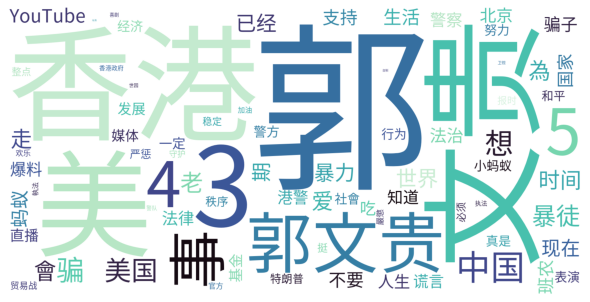

In [22]:
topic_to_wordcloud_zh(all_word_list, df19_zh_text['tweet_text'])

In [ ]:
萌萌豹 10194
	 4面岂几歌 9852
	 gwalcki4 9149
	 Alleen 4402
	 番茄不是西红柿 3912
	 澎湖湾海燕 3885
	 露水佳人 3881
	 舞随风动 3616
	 Dream News 3364
	 西丽 3211

In [ ]:
df19_user3 = df19[df19['user_display_name'] == '萌萌豹']
df19_user3['tweet_text'].head(20)

In [ ]:
df19_user1 = df19[df19['user_screen_name'] == 'HKpoliticalnew']
df19_user2 = df19[df19['user_screen_name'] == 'ctcc507']
print(len(df19_user1), len(df19_user2))

# both accounts tweeted significantly less than the actual top users (see above)

In [ ]:
df19_user1['tweet_text'].head(20)

In [ ]:
print(len(df19_user1))

df19_user1 = df19_user1[~df19_user1['tweet_text'].str.startswith('RT')]
print("after removing retweets:", len(df19_user1))

df19_user1['tweet_text'].head(20)

In [ ]:
df19_user1['tweet_text'] = df19_user1['tweet_text'].str.replace(r'http\S+', '')
df19_user1['tweet_text'] = df19_user1['tweet_text'].str.replace(r'[A-Za-z@+#=_0-9,，.!]', '')

In [ ]:
df19_user1['tweet_text'].head(20)

In [ ]:
blanks = []
for i, tweet in df19_user1['tweet_text'].iteritems():  # iterate over the DataFrame
    if type(tweet)==str:            # avoid NaN values
        if tweet.isspace() or tweet == "":         # test 'review' for whitespace
            blanks.append(i)     # add matching index numbers to the list
            
print('Number of blanks:', len(blanks))

df19_user1.drop(blanks, inplace=True)

In [ ]:
print(len(df19_user1))
df19_user1['tweet_text'].head(20)

In [ ]:
all_word_list = find_topics_words_zh(df19_user1, 10, 10)

In [ ]:
df19_user2['tweet_text'].head(5)

In [ ]:
print(len(df19_user2))

#df19_user2 = df19_user2[~df19_user2['tweet_text'].str.startswith('#整点报时')]
df19_user2 = df19_user2[~df19_user2['tweet_text'].str.contains(r'[0-9][0-9]:[0-9][0-9][AP]M')]
print("after removing retweets:", len(df19_user2))

In [ ]:
df19_user2['tweet_text'].head(5)

In [ ]:
print(len(df19_user2))

df19_user2 = df19_user2[~df19_user2['tweet_text'].str.contains('http')]
print("after removing retweets:", len(df19_user2))

In [ ]:
df19_user2['tweet_text'].head(40)

In [ ]:
stop_words_en = stopwords.words('english')
stop_words_en += list(string.punctuation)
stop_words_en += ['rt', '’', '\'s', '``', '\'\'', '““', 'n\'t', 'amp', 'u' , '']
lemmatizer = WordNetLemmatizer()

def find_topics_words_en(tweet_col, n_components, num_words):
    tfidf = TfidfVectorizer(max_df=0.8, min_df=5, stop_words=stop_words_en)
    dtm = tfidf.fit_transform(tweet_col)


    nmf_model = NMF(n_components=n_components, random_state=2)
    nmf_model.fit(dtm)
    
  
    all_word_list = []
    
    for index, topic in enumerate(nmf_model.components_):
        print(f"The top {num_words} words for topic # {index + 1}")
        word_list = [tfidf.get_feature_names()[i] for i in topic.argsort()[-num_words:]]
        all_word_list.append(word_list)
        print(word_list)
        print("\n")
    
    return all_word_list


